# Supporting Modules

In [1]:
# @title
import torch
import math

# from tqdm.auto import tqdm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# @title
class SpectralLayout:
    """
    Single source of truth for all tensor dimensions, slicing structures,
    and physics routing to eliminate magic numbers across the architecture.
    """
    # --- 0. Core Physical Constants ---
    EPS_MATH = 1e-8      # Algebraic safety (divide-by-zero prevention)
    EPS_PHYSICS = 1e-6   # Minimum threshold for spatial/mass existence

    # --- 1. Core Topological Truths ---
    COEFF_DIM_KEYS = ["Segments", "Bounds", "Chebyshev"]
    META_DIM_KEYS = ["Channels"]

    PHYSICS_DIMS_COEFFS = len(COEFF_DIM_KEYS)
    PHYSICS_DIMS_META = len(META_DIM_KEYS)

    LOGICAL_MATRIX_DIMS = 2
    MIN_TRANSPOSE_NDIM = LOGICAL_MATRIX_DIMS + PHYSICS_DIMS_COEFFS

    # --- 2. Derived Axis Indices ---
    DIM_SEGMENTS = -PHYSICS_DIMS_COEFFS + COEFF_DIM_KEYS.index("Segments")
    DIM_BOUNDS   = -PHYSICS_DIMS_COEFFS + COEFF_DIM_KEYS.index("Bounds")
    DIM_CHEB     = -PHYSICS_DIMS_COEFFS + COEFF_DIM_KEYS.index("Chebyshev")

    # UPDATED: Formally define the metadata channel dimension
    DIM_META_CHANNELS = -PHYSICS_DIMS_META + META_DIM_KEYS.index("Channels")

    # --- 3. Inner Domain Keys ---
    BOUND_KEYS = ["lower", "upper"]
    CHEB_KEYS = ["c0", "c1", "c2", "c3"]
    # UPDATED: Added 'L' for the physical spatial interval
    META_KEYS = ["z_real", "z_virt", "m_real", "m_virt", "L", "confidence"]

    # --- 4. Derived Slicing Maps (Native Python Objects) ---
    # Standard loops bypass Python's comprehension scope trap inside classes
    COEFFS_MAP = {}
    for k in BOUND_KEYS:
        COEFFS_MAP[k] = (Ellipsis, BOUND_KEYS.index(k), slice(None))

    CHEB_MAP = {}
    for k in CHEB_KEYS:
        CHEB_MAP[k] = (Ellipsis, CHEB_KEYS.index(k))

    META_MAP = {}
    for k in META_KEYS:
        META_MAP[k] = (Ellipsis, slice(META_KEYS.index(k), META_KEYS.index(k) + 1))

    # Clean up the loop variable so it doesn't stay in the class namespace
    del k

    # --- 5. Operational Transposition Config ---
    SHAPE_SLICE = slice(None, DIM_SEGMENTS) # Dynamically equates to [:-3]

    LOGICAL_AXES = {
        # Transpose swaps Row (left by MATRIX_DIMS) and Col (left by 1)
        "coeffs": (-(PHYSICS_DIMS_COEFFS + LOGICAL_MATRIX_DIMS), -(PHYSICS_DIMS_COEFFS + 1)),
        "meta": (-(PHYSICS_DIMS_META + LOGICAL_MATRIX_DIMS), -(PHYSICS_DIMS_META + 1))
    }

    # --- 6. Transient Broadcasting Indices ---
    # Used strictly during matrix multiplication to align M, K, N grids.
    # We insert dummy matrix dimensions to the left of the Meta Physics block.

    # Insert N (Columns) exactly 1 step left of the physics block
    DIM_BROADCAST_N = -(PHYSICS_DIMS_META + 1)

    # Insert M (Rows) exactly 2 steps left of the physics block
    # PyTorch unsqueeze counts backward from the OUTPUT rank (+1 offset required)
    DIM_BROADCAST_M = -(PHYSICS_DIMS_META + LOGICAL_MATRIX_DIMS + 1)

    # Post-broadcast, the shared K dimension shifts to where M was inserted
    DIM_REDUCE_K    = -(PHYSICS_DIMS_META + LOGICAL_MATRIX_DIMS)


class SpectralTensor:
    def __init__(self, coeffs: torch.Tensor, meta: torch.Tensor):
        self.coeffs = coeffs
        self.meta = meta

    @property
    def shape(self):
        """Logical geometric shape, strictly excluding spectral physics dims."""
        return self.coeffs.shape[SpectralLayout.SHAPE_SLICE]

    def __add__(self, other):
        return SpectralAlgebra.add(self, other)

    def __mul__(self, other):
        return SpectralAlgebra.multiply(self, other)

    def __matmul__(self, other):
        return SpectralAlgebra.matmul(self, other)

    @property
    def T(self):
        """Transposes the last two logical dimensions."""
        if self.coeffs.ndim < SpectralLayout.MIN_TRANSPOSE_NDIM:
            return self

        new_coeffs = self.coeffs.transpose(*SpectralLayout.LOGICAL_AXES["coeffs"])
        new_meta = self.meta.transpose(*SpectralLayout.LOGICAL_AXES["meta"])

        return SpectralTensor(new_coeffs, new_meta)

    @classmethod
    def concatenate(cls, tensors, dim=0):
        new_coeffs = torch.cat([t.coeffs for t in tensors], dim=dim)
        new_meta = torch.cat([t.meta for t in tensors], dim=dim)
        return cls(new_coeffs, new_meta)


class SpectralTopology:
    """Handles the structural upsampling and downsampling of Chebyshev splines."""

    _m_split_2 = None
    _m_merge_2 = None
    _merge_cache = {}
    _split_cache = {}

    @classmethod
    def _get_base_matrices(cls, device='cpu'):
        if cls._m_split_2 is None or cls._m_split_2.device != torch.device(device):
            m_left = torch.tensor([
                [ 1.0,  0.0,  0.0,  0.0 ],
                [-0.5,  0.5,  0.0,  0.0 ],
                [-0.25, -1.0,  0.25, 0.0 ],
                [ 0.25,  0.375, -0.75, 0.125]
            ], device=device)

            m_right = torch.tensor([
                [ 1.0,  0.0,  0.0,  0.0 ],
                [ 0.5,  0.5,  0.0,  0.0 ],
                [-0.25,  1.0,  0.25, 0.0 ],
                [-0.25,  0.375,  0.75, 0.125]
            ], device=device)

            cls._m_split_2 = torch.cat([m_left, m_right], dim=1)
            # The merge matrix is the exact mathematical pseudo-inverse of the split matrix
            cls._m_merge_2 = torch.linalg.pinv(cls._m_split_2)

            cls._merge_cache[1] = torch.eye(4, device=device)
            cls._split_cache[1] = torch.eye(4, device=device)
            cls._merge_cache[2] = cls._m_merge_2
            cls._split_cache[2] = cls._m_split_2

        return cls._m_split_2, cls._m_merge_2

    @classmethod
    def _get_merge_jump(cls, ratio, device='cpu'):
        cls._get_base_matrices(device)
        if ratio in cls._merge_cache: return cls._merge_cache[ratio]
        half_ratio = ratio // 2
        m_half = cls._get_merge_jump(half_ratio, device)
        block_m = torch.block_diag(*([cls._m_merge_2] * half_ratio))
        m_full = torch.matmul(block_m, m_half)
        cls._merge_cache[ratio] = m_full
        return m_full

    @classmethod
    def _get_split_jump(cls, ratio, device='cpu'):
        cls._get_base_matrices(device)
        if ratio in cls._split_cache: return cls._split_cache[ratio]
        half_ratio = ratio // 2
        m_half = cls._get_split_jump(half_ratio, device)
        block_m = torch.block_diag(*([cls._m_split_2] * half_ratio))
        m_full = torch.matmul(m_half, block_m)
        cls._split_cache[ratio] = m_full
        return m_full

    @classmethod
    def upsample_to_match(cls, coeffs_A, coeffs_B):
        s_A = coeffs_A.shape[SpectralLayout.DIM_SEGMENTS]
        s_B = coeffs_B.shape[SpectralLayout.DIM_SEGMENTS]
        target_s = max(s_A, s_B)
        return cls._upsample_segments(coeffs_A, target_s), cls._upsample_segments(coeffs_B, target_s)

    @classmethod
    def _upsample_segments(cls, coeffs, target_s):
        current_s = coeffs.shape[SpectralLayout.DIM_SEGMENTS]
        if current_s == target_s: return coeffs

        ratio = target_s // current_s
        m_jump = cls._get_split_jump(ratio, coeffs.device)
        projected = torch.matmul(coeffs, m_jump)

        shape = list(projected.shape)
        # Isolate the derived physics dimensions to safely reshape
        reshaped = projected.reshape(
            *shape[:SpectralLayout.DIM_CHEB],
            ratio,
            len(SpectralLayout.CHEB_KEYS)
        )
        transposed = reshaped.transpose(-2, -3) # Swap internal transient bounds/ratio dims

        return transposed.reshape(
            *shape[:SpectralLayout.DIM_SEGMENTS],
            target_s,
            len(SpectralLayout.BOUND_KEYS),
            len(SpectralLayout.CHEB_KEYS)
        )

    @classmethod
    def enforce_left_complexity(cls, result_coeffs, target_s):
        current_s = result_coeffs.shape[SpectralLayout.DIM_SEGMENTS]
        if current_s == target_s: return result_coeffs

        ratio = current_s // target_s
        m_jump = cls._get_merge_jump(ratio, result_coeffs.device)

        shape = list(result_coeffs.shape)
        reshaped = result_coeffs.reshape(
            *shape[:SpectralLayout.DIM_SEGMENTS],
            target_s,
            ratio,
            len(SpectralLayout.BOUND_KEYS),
            len(SpectralLayout.CHEB_KEYS)
        )
        transposed = reshaped.transpose(-2, -3) # Swap internal transient bounds/ratio dims
        flattened = transposed.reshape(
            *shape[:SpectralLayout.DIM_SEGMENTS],
            target_s,
            len(SpectralLayout.BOUND_KEYS),
            ratio * len(SpectralLayout.CHEB_KEYS)
        )

        return torch.matmul(flattened, m_jump)


class ChebyshevMath:
    """Handles pure Order-3 Chebyshev polynomial operations and node evaluations."""
    _cheb_mul_tensor = None
    _cheb_nodes = None
    _cheb_inv_matrix = None

    @classmethod
    def get_mul_tensor(cls, device):
        if cls._cheb_mul_tensor is None or cls._cheb_mul_tensor.device != torch.device(device):
            tensor = torch.zeros((4, 4, 4), device=device)
            for i in range(4):
                for j in range(4):
                    if (i + j) < 4: tensor[i + j, i, j] += 0.5
                    if abs(i - j) < 4: tensor[abs(i - j), i, j] += 0.5
            cls._cheb_mul_tensor = tensor
        return cls._cheb_mul_tensor

    @classmethod
    def get_interp_matrices(cls, device):
        if cls._cheb_nodes is None or cls._cheb_nodes.device != torch.device(device):
            k = torch.arange(1, 5, dtype=torch.float32, device=device)
            nodes = torch.cos(((2 * k - 1) * torch.pi) / 8.0)
            cls._cheb_nodes = nodes

            T = torch.zeros((4, 4), device=device)
            T[:, 0] = 1.0
            T[:, 1] = nodes
            T[:, 2] = 2 * nodes**2 - 1.0
            T[:, 3] = 4 * nodes**3 - 3 * nodes
            cls._cheb_inv_matrix = torch.linalg.pinv(T)
        return cls._cheb_nodes, cls._cheb_inv_matrix

    @staticmethod
    def to_mu_err(coeffs):
        lower = coeffs[SpectralLayout.COEFFS_MAP["lower"]]
        upper = coeffs[SpectralLayout.COEFFS_MAP["upper"]]
        return (upper + lower) / 2.0, (upper - lower) / 2.0

    @staticmethod
    def to_bounds(mu, err):
        err = torch.abs(err)
        return torch.stack([mu - err, mu + err], dim=SpectralLayout.DIM_BOUNDS)

    @staticmethod
    def evaluate_at_nodes(coeffs, nodes):
        c0 = coeffs[SpectralLayout.CHEB_MAP["c0"]].unsqueeze(-1)
        c1 = coeffs[SpectralLayout.CHEB_MAP["c1"]].unsqueeze(-1)
        c2 = coeffs[SpectralLayout.CHEB_MAP["c2"]].unsqueeze(-1)
        c3 = coeffs[SpectralLayout.CHEB_MAP["c3"]].unsqueeze(-1)
        return c0 + c1 * nodes + c2 * (2 * nodes**2 - 1.0) + c3 * (4 * nodes**3 - 3 * nodes)

    @staticmethod
    def get_stretch_partitions(coeffs):
        """
        Branchless Hahn Decomposition to find the Positive (S_pos)
        and Negative (S_neg) spatial stretch of a piece-wise Chebyshev token.
        """
        c1 = coeffs[SpectralLayout.CHEB_MAP["c1"]]
        c2 = coeffs[SpectralLayout.CHEB_MAP["c2"]]
        c3 = coeffs[SpectralLayout.CHEB_MAP["c3"]]

        # Derivative C'(x) is a quadratic: Ax^2 + Bx + C_term
        A = 12.0 * c3
        B = 4.0 * c2
        C_term = c1 - 3.0 * c3

        # Safe-guard A to prevent division by zero for pure linear curves
        A_safe = A + torch.sign(A) * SpectralLayout.EPS_MATH + (A == 0) * SpectralLayout.EPS_MATH

        discriminant = B**2 - 4.0 * A_safe * C_term
        sqrt_disc = torch.sqrt(torch.relu(discriminant))

        r1 = (-B - sqrt_disc) / (2.0 * A_safe)
        r2 = (-B + sqrt_disc) / (2.0 * A_safe)

        r_min = torch.clamp(torch.min(r1, r2), -1.0, 1.0)
        r_max = torch.clamp(torch.max(r1, r2), -1.0, 1.0)

        def eval_poly(x):
            c0_x = coeffs[SpectralLayout.CHEB_MAP["c0"]]
            return c0_x + c1*x + c2*(2.0*x**2 - 1.0) + c3*(4.0*x**3 - 3.0*x)

        delta_1 = eval_poly(r_min) - eval_poly(-1.0)
        delta_2 = eval_poly(r_max) - eval_poly(r_min)
        delta_3 = eval_poly(1.0) - eval_poly(r_max)

        S_pos = torch.relu(delta_1) + torch.relu(delta_2) + torch.relu(delta_3)
        S_neg = torch.relu(-delta_1) + torch.relu(-delta_2) + torch.relu(-delta_3)

        return S_pos + SpectralLayout.EPS_PHYSICS, S_neg + SpectralLayout.EPS_PHYSICS


class KinematicPhysics:
    """Handles spatial metadata and coordinate routing."""

    @classmethod
    def interact(cls, meta_A, meta_B, mode="add", S_pos=None, S_neg=None):
        """
        Physical metadata interaction enforcing the A + A equivalency rules,
        spatial dragging, and Cauchy gravity density calculations.
        """
        # Unpack Metadata (A is the Target/Inner token, B is the Operator/Outer token)
        z_A_r = meta_A[SpectralLayout.META_MAP["z_real"]]
        z_A_v = meta_A[SpectralLayout.META_MAP["z_virt"]]
        m_A_r = meta_A[SpectralLayout.META_MAP["m_real"]]
        m_A_v = meta_A[SpectralLayout.META_MAP["m_virt"]]
        L_A   = meta_A[SpectralLayout.META_MAP["L"]]
        c_A   = meta_A[SpectralLayout.META_MAP["confidence"]]

        z_B_r = meta_B[SpectralLayout.META_MAP["z_real"]]
        z_B_v = meta_B[SpectralLayout.META_MAP["z_virt"]]
        m_B_r = meta_B[SpectralLayout.META_MAP["m_real"]]
        m_B_v = meta_B[SpectralLayout.META_MAP["m_virt"]]
        L_B   = meta_B[SpectralLayout.META_MAP["L"]]
        c_B   = meta_B[SpectralLayout.META_MAP["confidence"]]

        mag_A = torch.sqrt(m_A_r**2 + m_A_v**2) + SpectralLayout.EPS_PHYSICS
        mag_B = torch.sqrt(m_B_r**2 + m_B_v**2) + SpectralLayout.EPS_PHYSICS
        total_mag = mag_A + mag_B

        # 1. SPATIAL DRAGGING (Gravity-Weighted Centroid)
        z_new_r = (z_A_r * mag_A + z_B_r * mag_B) / total_mag
        z_new_v = (z_A_v * mag_A + z_B_v * mag_B) / total_mag

        # 2. ALGEBRAIC MASS EQUIVALENCE & HAHN DECOMPOSITION
        if mode == "add":
            m_new_r = m_A_r + m_B_r
            m_new_v = m_A_v + m_B_v
        elif mode == "mul":
            # Multiplicative density cross-scales like complex magnitudes
            m_new_r = m_A_r * m_B_r + m_A_v * m_B_v
            m_new_v = m_A_r * m_B_v + m_A_v * m_B_r
        elif mode == "comp":
            # Hahn Decomposition Fold
            # S_pos preserves axis identity. S_neg flips axis identity (folding backward twice = forward).
            m_new_r = m_A_r * S_pos + m_A_v * S_neg
            m_new_v = m_A_v * S_pos + m_A_r * S_neg
        else:
            raise ValueError(f"Unknown mode: {mode}")

        # 3. GLOBAL INTERVAL (The Bounding Box Union)
        left_edge = torch.min(z_A_r - L_A / 2.0, z_B_r - L_B / 2.0)
        right_edge = torch.max(z_A_r + L_A / 2.0, z_B_r + L_B / 2.0)
        L_new = torch.max(right_edge - left_edge, torch.tensor(SpectralLayout.EPS_PHYSICS, device=z_A_r.device))

        # 4. CAUCHY GRAVITY & CONFIDENCE PENALTY
        D = torch.abs(z_A_r - z_B_r)
        R = (L_A + L_B) / 2.0 + SpectralLayout.EPS_PHYSICS
        gravity = (R**2) / (R**2 + D**2)

        base_c = (c_A * mag_A + c_B * mag_B) / total_mag
        c_new = base_c * gravity

        return torch.cat([z_new_r, z_new_v, m_new_r, m_new_v, L_new, c_new], dim=-1)

    @classmethod
    def merge_matmul(cls, meta_A, meta_B):
        # 1. BROADCASTING
        meta_A_ext = meta_A.unsqueeze(SpectralLayout.DIM_BROADCAST_N)
        meta_B_ext = meta_B.unsqueeze(SpectralLayout.DIM_BROADCAST_M)

        # 2. MULTIPLICATION
        accum = cls.interact(meta_A_ext, meta_B_ext, mode="mul")

        # 3. PARALLEL BINARY TREE REDUCTION
        dim_k = SpectralLayout.DIM_REDUCE_K
        while accum.shape[dim_k] > 1:
            K_current = accum.shape[dim_k]
            half = K_current // 2

            # Using torch.split or slice objects to avoid hardcoded ellipsis slicing
            left, right, *remainder = torch.split(accum, [half, half, K_current - 2*half], dim=dim_k)

            reduced = cls.interact(left, right, mode="add")

            if remainder and remainder[0].shape[dim_k] > 0:
                accum = torch.cat([reduced, remainder[0]], dim=dim_k)
            else:
                accum = reduced

        return accum.squeeze(dim_k)


class SpectralAlgebra:
    """High-level orchestration of continuous topology operations."""

    @classmethod
    def add(cls, tensor_A, tensor_B):
        target_s = tensor_A.coeffs.shape[SpectralLayout.DIM_SEGMENTS]
        A_align, B_align = SpectralTopology.upsample_to_match(tensor_A.coeffs, tensor_B.coeffs)

        new_coeffs = A_align + B_align
        final_coeffs = SpectralTopology.enforce_left_complexity(new_coeffs, target_s)

        # UPDATED: Replaced merge_elementwise with interact
        new_meta = KinematicPhysics.interact(tensor_A.meta, tensor_B.meta, mode="add")
        return tensor_A.__class__(final_coeffs, new_meta)

    @classmethod
    def multiply(cls, tensor_A, tensor_B):
        target_s = tensor_A.coeffs.shape[SpectralLayout.DIM_SEGMENTS]
        A_align, B_align = SpectralTopology.upsample_to_match(tensor_A.coeffs, tensor_B.coeffs)

        mu_A, err_A = ChebyshevMath.to_mu_err(A_align)
        mu_B, err_B = ChebyshevMath.to_mu_err(B_align)
        mul_map = ChebyshevMath.get_mul_tensor(A_align.device)

        mu_new = torch.einsum('kij,...ai,...aj->...ak', mul_map, mu_A, mu_B)

        mag_A = torch.sum(torch.abs(mu_A), dim=-1, keepdim=True)
        mag_B = torch.sum(torch.abs(mu_B), dim=-1, keepdim=True)
        err_new = (mag_A * err_B) + (mag_B * err_A) + torch.einsum('kij,...ai,...aj->...ak', mul_map, err_A, err_B)

        new_coeffs = ChebyshevMath.to_bounds(mu_new, err_new)
        final_coeffs = SpectralTopology.enforce_left_complexity(new_coeffs, target_s)

        # UPDATED: Replaced merge_elementwise with interact
        new_meta = KinematicPhysics.interact(tensor_A.meta, tensor_B.meta, mode="mul")
        return tensor_A.__class__(final_coeffs, new_meta)

    @classmethod
    def matmul(cls, tensor_A, tensor_B):
        target_s = tensor_A.coeffs.shape[SpectralLayout.DIM_SEGMENTS]
        A_align, B_align = SpectralTopology.upsample_to_match(tensor_A.coeffs, tensor_B.coeffs)

        mu_A, err_A = ChebyshevMath.to_mu_err(A_align)
        mu_B, err_B = ChebyshevMath.to_mu_err(B_align)
        mul_map = ChebyshevMath.get_mul_tensor(A_align.device)

        # FIXED EINSUM VARIABLES:
        # Chebyshev dimensions: c=out_deg, a=in1_deg, b=in2_deg
        # Logical dimensions: m=Row, x=Inner, n=Col
        # Physics dimensions: s=Segments

        # 1. Expected Semantic Target
        mu_new = torch.einsum('cab,...mxsa,...xnsb->...mnsc', mul_map, mu_A, mu_B)

        # 2. Uncertainty Propagation
        mag_A = torch.sum(torch.abs(mu_A), dim=-1) # Shape: [..., M, X, S]
        mag_B = torch.sum(torch.abs(mu_B), dim=-1) # Shape: [..., X, N, S]

        err_new = (
            torch.einsum('...mxs,...xnsc->...mnsc', mag_A, err_B) +
            torch.einsum('...xns,...mxsc->...mnsc', mag_B, err_A) +
            torch.einsum('cab,...mxsa,...xnsb->...mnsc', mul_map, err_A, err_B)
        )

        new_coeffs = ChebyshevMath.to_bounds(mu_new, err_new)
        final_coeffs = SpectralTopology.enforce_left_complexity(new_coeffs, target_s)

        # 'x' used as the inner metadata contraction dimension
        new_meta = KinematicPhysics.merge_matmul(tensor_A.meta, tensor_B.meta)

        return tensor_A.__class__(final_coeffs, new_meta)

    @classmethod
    def composition(cls, composer, composee):
        target_s = composer.coeffs.shape[SpectralLayout.DIM_SEGMENTS]
        f_align, g_align = SpectralTopology.upsample_to_match(composer.coeffs, composee.coeffs)

        mu_g, err_g = ChebyshevMath.to_mu_err(g_align)
        mu_f, err_f = ChebyshevMath.to_mu_err(f_align)
        nodes, inv_matrix = ChebyshevMath.get_interp_matrices(g_align.device)

        z_i = torch.clamp(ChebyshevMath.evaluate_at_nodes(mu_g, nodes), -1.0, 1.0)
        err_g_evals = torch.abs(ChebyshevMath.evaluate_at_nodes(err_g, nodes))

        mu_out_evals = ChebyshevMath.evaluate_at_nodes(mu_f, z_i)
        err_f_evals = torch.abs(ChebyshevMath.evaluate_at_nodes(err_f, z_i))

        # We can keep the f_prime derivation for polynomial error propagation
        f1 = mu_f[SpectralLayout.CHEB_MAP["c1"]].unsqueeze(-1)
        f2 = mu_f[SpectralLayout.CHEB_MAP["c2"]].unsqueeze(-1)
        f3 = mu_f[SpectralLayout.CHEB_MAP["c3"]].unsqueeze(-1)
        f_prime = torch.abs(f1 + 4.0 * f2 * z_i + f3 * (12.0 * z_i**2 - 3.0))

        err_out_evals = (f_prime * err_g_evals) + err_f_evals

        mu_out = torch.matmul(mu_out_evals, inv_matrix.T)
        err_out = torch.matmul(err_out_evals, inv_matrix.T)

        new_coeffs = ChebyshevMath.to_bounds(mu_out, err_out)
        final_coeffs = SpectralTopology.enforce_left_complexity(new_coeffs, target_s)

        # UPDATED: Get the Hahn partitions from the composer (outer function)
        S_pos, S_neg = ChebyshevMath.get_stretch_partitions(mu_f)

        # Aggregate the stretch across all segments and divide by 2.0 to get the Average Derivative
        # (Since the global parameter space is always normalized to length 2.0)
        S_pos = S_pos.sum(dim=-1).unsqueeze(SpectralLayout.DIM_META_CHANNELS) / 2.0
        S_neg = S_neg.sum(dim=-1).unsqueeze(SpectralLayout.DIM_META_CHANNELS) / 2.0

        # UPDATED: Pass composee (inner) as A, composer (outer) as B
        new_meta = KinematicPhysics.interact(composee.meta, composer.meta, mode="comp", S_pos=S_pos, S_neg=S_neg)
        return composer.__class__(final_coeffs, new_meta)

    @staticmethod
    def integrate(tensor_A):
        c0 = tensor_A.coeffs[SpectralLayout.CHEB_MAP["c0"]]
        c2 = tensor_A.coeffs[SpectralLayout.CHEB_MAP["c2"]]
        integrals = (2.0 * c0) - ((2.0 / 3.0) * c2)
        confidence = tensor_A.meta[SpectralLayout.META_MAP["confidence"]]

        # Add a singleton dimension so [..., 1] broadcasts across [..., S, B]
        confidence = confidence.unsqueeze(-1)

        return (integrals * confidence).mean(dim=(-1, -2))

In [3]:
# @title
class _GlobalCanvasFramer:
    """Pads the entire ND tensor to a perfect global power of 2."""
    def pad_to_pow2(self, raw_nd_data):
        shape = raw_nd_data.shape
        pow2_shape = [1 << (s - 1).bit_length() if s > 1 else 1 for s in shape]

        pad_config = []
        for s, p2 in zip(reversed(shape), reversed(pow2_shape)):
            pad_config.extend([0, p2 - s])

        if any(p > 0 for p in pad_config):
            import torch.nn.functional as F
            return F.pad(raw_nd_data, tuple(pad_config), mode='constant', value=0.0)
        return raw_nd_data

    def unpad(self, canvas, target_shape):
        slices = tuple(slice(0, s) for s in target_shape)
        return canvas[slices]

class _ZCurveRouter:
    """Sweeps a perfectly padded power-of-2 canvas in a single continuous pass."""
    def __init__(self, min_token_size):
        self.min_token_size = min_token_size

    def get_permutation(self, shape_nd):
        n_total = math.prod(shape_nd)
        flat_indices = torch.arange(n_total)

        temp = flat_indices
        coords = []
        for dim_size in reversed(shape_nd):
            coords.insert(0, temp % dim_size)
            temp = temp // dim_size

        z_code = torch.zeros(n_total, dtype=torch.int64)
        max_bits = max([(s - 1).bit_length() for s in shape_nd])

        shift = 0
        for bit in range(max_bits):
            for dim, dim_size in enumerate(shape_nd):
                if bit < (dim_size - 1).bit_length():
                    z_code |= ((coords[dim] >> bit) & 1) << shift
                    shift += 1

        return torch.argsort(z_code)

    def sequence(self, padded_nd):
        shape = list(padded_nd.shape)
        perm = self.get_permutation(shape)
        flat_pixels = padded_nd.flatten()[perm]

        # Generate exact spatial bounding boxes for the 1D chunks
        grids = [torch.arange(s) for s in shape]
        coords_nd = torch.stack([m.flatten() for m in torch.meshgrid(*grids, indexing='ij')], dim=1)
        sorted_coords = coords_nd[perm]

        grouped_coords = sorted_coords.view(-1, self.min_token_size, len(shape))
        mins = grouped_coords.min(dim=1)[0]
        maxs = grouped_coords.max(dim=1)[0] + 1
        intervals = torch.cat([mins, maxs], dim=1)

        return flat_pixels, intervals

    def unsequence(self, raw_1d, padded_shape):
        perm = self.get_permutation(padded_shape)
        flat_canvas = torch.zeros_like(raw_1d)
        flat_canvas[perm] = raw_1d
        return flat_canvas.view(*padded_shape)

class GeometryInterpreter:
    """The Universal Spatial Boundary."""
    def __init__(self, config):
        self.framer = _GlobalCanvasFramer()
        self.router = _ZCurveRouter(config.min_patch_size)

    def flatten_to_1d(self, raw_nd_data, task_metadata):
        padded = self.framer.pad_to_pow2(raw_nd_data)
        return self.router.sequence(padded)

    def unflatten_to_nd(self, raw_1d_data, spatial_intervals, task_metadata):
        target_shape = task_metadata["shape"]
        padded_shape = [1 << (s - 1).bit_length() if s > 1 else 1 for s in target_shape]

        padded_canvas = self.router.unsequence(raw_1d_data, padded_shape)
        return self.framer.unpad(padded_canvas, target_shape)

In [4]:
# @title
class _BaseLeafMinter:
    """Projects raw 1D data into base Level 0 single-curve polynomials."""
    def __init__(self, leaf_basis, recon_basis):
        self.leaf_basis = leaf_basis
        self.recon_basis = recon_basis

    def mint(self, raw_1d_data, spatial_intervals):
        patches = self._chunk(raw_1d_data, spatial_intervals)
        coeffs_mu = self._project(patches)
        coeffs_dual = coeffs_mu.unsqueeze(1).expand(-1, 2, -1)
        sigma, max_err = self._calculate_error(patches, coeffs_mu)

        return {
            "coeffs": coeffs_dual,
            "intervals": spatial_intervals,
            "sigma": sigma,
            "max_err": max_err
        }

    def _chunk(self, raw_1d_data, spatial_intervals):
        chunk_size = raw_1d_data.shape[0] // spatial_intervals.shape[0]
        return raw_1d_data.view(-1, chunk_size)

    def _project(self, patches):
        return torch.matmul(patches, self.leaf_basis)

    def _calculate_error(self, patches, coeffs_mu):
        recon = torch.matmul(coeffs_mu, self.recon_basis.t())
        residuals = patches - recon
        sigma = torch.sqrt(torch.mean(residuals**2, dim=1, keepdim=True))
        max_err, _ = torch.max(torch.abs(residuals), dim=1, keepdim=True)
        return sigma, max_err


class _TopologicalPyramid:
    """Iteratively merges adjacent tokens to map the continuous error landscape."""
    def build(self, initial_level):
        pyramid = [initial_level]
        current = initial_level

        while current["coeffs"].shape[0] > 1:
            merged_level = self._merge_level(current)
            pyramid.append(merged_level)
            current = merged_level

        return pyramid

    def _merge_level(self, current_level):
        paired_coeffs = self._pair(current_level["coeffs"])
        paired_sigmas = self._pair(current_level["sigma"])
        paired_max_errs = self._pair(current_level["max_err"])
        paired_intervals = self._pair(current_level["intervals"])

        merged_coeffs = self._topological_merge(paired_coeffs)
        distortion_mag = self._calculate_distortion(paired_coeffs, merged_coeffs)
        new_sigma, new_max = self._inflate_errors(paired_sigmas, paired_max_errs, distortion_mag)

        return {
            "coeffs": merged_coeffs.squeeze(1),
            "intervals": self._union_intervals(paired_intervals),
            "sigma": new_sigma,
            "max_err": new_max
        }

    def _pair(self, tensor):
        return tensor.view(-1, 2, *tensor.shape[1:])

    def _topological_merge(self, paired_coeffs):
        # paired_coeffs is natively [N//2, S=2, B=2, C=4]. No dummy dims needed!
        return SpectralTopology.enforce_left_complexity(paired_coeffs, target_s=1)

    def _calculate_distortion(self, paired_coeffs, merged_coeffs):
        # Both tensors are natively B=2, pass them directly
        upsampled, _ = SpectralTopology.upsample_to_match(merged_coeffs, paired_coeffs)
        distortion = torch.abs(paired_coeffs - upsampled)

        # FIX: Changed .view() to .reshape() to handle non-contiguous memory strides
        return torch.max(distortion.reshape(distortion.shape[0], -1), dim=1, keepdim=True)[0]

    def _inflate_errors(self, paired_sigmas, paired_max_errs, distortion_mag):
        sig_A, sig_B = paired_sigmas[:, 0], paired_sigmas[:, 1]
        max_A, max_B = paired_max_errs[:, 0], paired_max_errs[:, 1]

        new_sigma = torch.sqrt((sig_A**2 + sig_B**2) / 2.0 + (distortion_mag * 0.52)**2)
        new_max_err = torch.max(max_A, max_B) + (distortion_mag * 0.72)
        return new_sigma, new_max_err

    def _union_intervals(self, paired_intervals):
        ndim = paired_intervals.shape[-1] // 2
        int_A, int_B = paired_intervals[:, 0], paired_intervals[:, 1]
        mins = torch.min(int_A[:, :ndim], int_B[:, :ndim])
        maxs = torch.max(int_A[:, ndim:], int_B[:, ndim:])
        return torch.cat([mins, maxs], dim=1)


class _PyramidWalker:
    """Executes a Batched Top-Down BFS using GPU Boolean Masking to eliminate CPU sync overhead."""
    def __init__(self, error_threshold, min_token_size):
        self.error_threshold = error_threshold
        self.min_token_size = min_token_size

    def walk(self, proto_pyramid):
        num_levels = len(proto_pyramid)
        root_level = num_levels - 1

        # Pull the device directly from the tensor to ensure it stays in VRAM
        device = proto_pyramid[0]["intervals"].device

        optimal_intervals = []
        optimal_1d_slices = []
        start_indices_tracker = []

        # At the root, there is 1 node, and it is actively being evaluated
        active_mask = torch.ones(proto_pyramid[root_level]["intervals"].shape[0], dtype=torch.bool, device=device)

        # Walk from the top of the pyramid down to the leaves
        for level in range(root_level, -1, -1):
            level_data = proto_pyramid[level]

            if level == 0:
                # Leaves cannot be split further. If they are active, they are valid.
                valid_mask = active_mask
                split_mask = torch.zeros_like(active_mask)
            else:
                # 1. BULLETPROOF DEVICE SYNC: Force errors to the exact same device as the mask
                errors = level_data["max_err"].to(device)

                # 2. Crush any extra dimensions by taking the max error
                if errors.dim() > 1:
                    errors = errors.max(dim=-1)[0]

                # 3. BULLETPROOF SCALAR: Force the threshold to be a pure Python float
                thresh = float(self.error_threshold)

                # Now, GPU Tensor <= Float, and GPU Tensor & GPU Tensor. Perfect harmony.
                valid_mask = active_mask & (errors <= thresh)

                # A node must split if it is active but its error is too high
                split_mask = active_mask & ~valid_mask

            # 1. Extract Valid Tokens (Simultaneous GPU pull)
            if valid_mask.any():
                optimal_intervals.append(level_data["intervals"][valid_mask])

                valid_indices = torch.nonzero(valid_mask, as_tuple=False).squeeze(-1)
                token_length = (1 << level) * self.min_token_size
                start_indices = valid_indices * token_length
                end_indices = start_indices + token_length

                # Store the exact spatial starts for sorting later
                start_indices_tracker.append(start_indices)

                # Create the [start, end] pairs just like the original code
                slices = torch.stack([start_indices, end_indices], dim=1).tolist()
                optimal_1d_slices.extend(slices)

            # 2. Propagate the Split Mask down to the Children (Level - 1)
            if level > 0:
                next_num_nodes = proto_pyramid[level - 1]["intervals"].shape[0]
                next_active_mask = torch.zeros(next_num_nodes, dtype=torch.bool, device=device)

                # Left children are at even indices, Right children are at odd indices
                next_active_mask[0::2] = split_mask
                next_active_mask[1::2] = split_mask

                active_mask = next_active_mask

        # 3. Final spatial re-ordering (Restore the Left-to-Right Z-Curve)
        if not optimal_intervals:
            return torch.empty((0, proto_pyramid[0]["intervals"].shape[1]), device=device), []

        final_intervals = torch.cat(optimal_intervals, dim=0)
        all_start_indices = torch.cat(start_indices_tracker, dim=0)

        # Sort everything instantly based on spatial starting position
        sort_idx = torch.argsort(all_start_indices)

        final_intervals = final_intervals[sort_idx]
        sorted_slices = [optimal_1d_slices[i] for i in sort_idx.tolist()]

        return final_intervals, sorted_slices


class _DualCurveFitter:
    """Uses Length-Bucketing to perform batched Chebyshev projections."""
    def __init__(self, config=None):
        self.config = config

    def fit(self, raw_1d_data, optimal_intervals, optimal_1d_slices):
        device = raw_1d_data.device
        num_tokens = len(optimal_1d_slices)

        # 1. Prepare the final output tensor
        # Assuming 4 Chebyshev coefficients per token (DC, x, 2x^2-1, 4x^3-3x)
        final_coeffs = torch.zeros((num_tokens, 4), dtype=torch.float32, device=device)

        # 2. Group slices by length
        length_groups = {}
        for i, (start, end) in enumerate(optimal_1d_slices):
            length = end - start
            if length not in length_groups:
                length_groups[length] = {'indices': [], 'starts': [], 'ends': []}
            length_groups[length]['indices'].append(i)
            length_groups[length]['starts'].append(start)
            length_groups[length]['ends'].append(end)

        # 3. Process each group as a massive batched tensor
        for length, group in length_groups.items():
            indices = group['indices']
            starts = group['starts']
            ends = group['ends']

            # Extract and stack all data slices of this exact length
            # shape: [batch_size, length]
            slices = [raw_1d_data[s:e] for s, e in zip(starts, ends)]
            stacked_data = torch.stack(slices, dim=0)

            # If the data has an extra channel dimension (e.g. [B, 1, Length]), squeeze it
            if stacked_data.dim() == 3:
                stacked_data = stacked_data.squeeze(1)

            # Generate the Chebyshev basis for this specific length
            x = torch.linspace(-1, 1, steps=length, device=device)
            A = torch.stack([torch.ones_like(x), x, 2*x**2-1, 4*x**3-3*x], dim=1) # [length, 4]

            # Calculate the mathematical pseudo-inverse
            A_pinv = torch.linalg.pinv(A) # [4, length]

            # THE MAGIC: Batched Matrix Multiplication
            # [batch_size, length] @ [length, 4] = [batch_size, 4]
            coeffs = torch.matmul(stacked_data, A_pinv.T)

            # Place the computed coefficients back into their original spatial order
            final_coeffs[indices] = coeffs

        # The Fitter must return the tensor with a channel dimension to match the minter
        # final shape: [num_tokens, 1, 4]
        # The Fitter must return a DUAL tensor (lower and upper bounds) to match the physics engine
        # final shape: [num_tokens, 2, 4]
        return final_coeffs.unsqueeze(1).expand(-1, 2, -1)


class _PhysicsMinter:
    """Attaches kinematic mass, length, and confidence bounds to the latent tokens."""
    def mint(self, dual_coeffs, optimal_intervals):
        kinematics = self._calc_kinematics(optimal_intervals)
        return {
            "coeffs": dual_coeffs,
            "intervals": optimal_intervals,
            "mass": kinematics["mass"],
            "length": kinematics["length"],
            "confidence": self._calc_confidence(dual_coeffs)
        }

    def _calc_kinematics(self, intervals):
        mass = torch.ones((intervals.shape[0], 1), dtype=torch.float32)
        return {"mass": mass, "length": self._calc_volume(intervals)}

    def _calc_volume(self, intervals):
        ndim = intervals.shape[1] // 2
        mins, maxs = intervals[:, :ndim], intervals[:, ndim:]
        return torch.prod(maxs - mins, dim=1, keepdim=True)

    def _calc_confidence(self, dual_coeffs):
        lower, upper = dual_coeffs[:, 0, :], dual_coeffs[:, 1, :]
        gap_mag = torch.norm(upper - lower, dim=1, keepdim=True)
        return 1.0 / (gap_mag + 1e-6)


class LatentEncoding:
    """The HQ for encoding physical streams into mathematically continuous topology."""
    def __init__(self, config):
        self.minter = _BaseLeafMinter(config.leaf_basis, config.reconstruction_basis)
        self.pyramid = _TopologicalPyramid()
        self.walker = _PyramidWalker(config.merge_threshold, config.min_patch_size)
        self.fitter = _DualCurveFitter()
        self.physics = _PhysicsMinter()

    def encode_stream(self, raw_1d_data, spatial_intervals):
        """Executes the 4 phases of continuous topological tokenization."""
        proto_leaves = self.minter.mint(raw_1d_data, spatial_intervals)
        proto_pyramid = self.pyramid.build(proto_leaves)

        opt_intervals, opt_slices = self.walker.walk(proto_pyramid)
        dual_coeffs = self.fitter.fit(raw_1d_data, opt_intervals, opt_slices)

        return self.physics.mint(dual_coeffs, opt_intervals)



In [5]:
# @title
class _EvaluationEngine:
    """Manages dynamic Chebyshev bases and executes discrete polynomial evaluation."""
    def __init__(self):
        self.cache = {}

    def evaluate(self, coeffs_list, lengths):
        """Evaluates a list of [4] coefficients into variable-length discrete segments."""
        segments = []
        for coeffs, length in zip(coeffs_list, lengths):
            basis = self._get_basis(length.item(), coeffs.device)
            segments.append(torch.matmul(basis, coeffs))
        return segments

    def _get_basis(self, seq_len, device):
        if seq_len in self.cache:
            return self.cache[seq_len]

        x = torch.linspace(-1, 1, steps=seq_len, device=device, dtype=torch.float32)
        A = torch.stack([
            torch.ones_like(x),
            x,
            2 * x**2 - 1,
            4 * x**3 - 3 * x
        ], dim=1)

        self.cache[seq_len] = A
        return A


class _SignalAssembler:
    """Translates spatial intervals into lengths, evaluates dual-curves, and stitches 1D arrays."""
    def __init__(self, engine):
        self.engine = engine

    def decode_and_stitch(self, dual_coeffs, intervals):
        lengths = self._get_lengths(intervals)

        # dual_coeffs is [N, B=2, C=4]. Evaluate Upper (idx 1) and Lower (idx 0)
        upper_eval = self.engine.evaluate(dual_coeffs[:, 1, :], lengths)
        lower_eval = self.engine.evaluate(dual_coeffs[:, 0, :], lengths)

        mean_segments = self._average_curves(upper_eval, lower_eval)
        return torch.cat(mean_segments, dim=0)

    def _get_lengths(self, intervals):
        """Calculates exact 1D pixel count based on ND spatial bounding box volume."""
        ndim = intervals.shape[1] // 2
        mins, maxs = intervals[:, :ndim], intervals[:, ndim:]
        return torch.prod(maxs - mins, dim=1).long()

    def _average_curves(self, upper_list, lower_list):
        return [(u + l) / 2.0 for u, l in zip(upper_list, lower_list)]


class LatentDecoding:
    """The HQ for decoding abstract topological polynomials back into physical 1D streams."""
    def __init__(self, config):
        self.engine = _EvaluationEngine()
        self.assembler = _SignalAssembler(self.engine)

    def decode_stream(self, latent_tokens, target_intervals):
        dual_coeffs = latent_tokens["coeffs"]
        return self.assembler.decode_and_stitch(dual_coeffs, target_intervals)



In [6]:
# @title
class Interface:
    """
    The Universal Boundary.
    Orchestrates the bidirectional flow between the physical N-Dimensional environment
    and the continuous 1D Latent Topological space.
    """
    def __init__(self, config):
        self.config = config
        self.geometry = GeometryInterpreter(config)
        self.encoder = LatentEncoding(config)
        self.decoder = LatentDecoding(config)

    def encode(self, raw_nd_data, task_metadata):
        """Flattens ND data to 1D, then mints the continuous Latent Tensors."""
        raw_1d, spatial_intervals = self.geometry.flatten_to_1d(raw_nd_data, task_metadata)
        latent_tokens = self.encoder.encode_stream(raw_1d, spatial_intervals)
        return latent_tokens

    def decode(self, latent_tokens, target_intervals, task_metadata):
        """Evaluates Latent Tensors back to 1D, then reconstructs the ND physical shape."""
        raw_1d = self.decoder.decode_stream(latent_tokens, target_intervals)
        reconstructed_nd = self.geometry.unflatten_to_nd(raw_1d, target_intervals, task_metadata)
        return reconstructed_nd

In [7]:
# @title
def fast_pytorch_kmeans(x, num_clusters, max_iters=50):
    """A fully vectorized K-Means implementation that stays in GPU VRAM."""
    # 1. Randomly initialize centroids from the data points
    indices = torch.randperm(x.shape[0], device=x.device)[:num_clusters]
    centroids = x[indices].clone()

    for _ in range(max_iters):
        # 2. Compute distances from all points to all centroids: [N, K]
        distances = torch.cdist(x, centroids)

        # 3. Find the closest centroid for each point: [N]
        labels = torch.argmin(distances, dim=1)

        # 4. Update centroids (Vectorized sum and divide)
        new_centroids = torch.zeros_like(centroids)
        counts = torch.bincount(labels, minlength=num_clusters).float().unsqueeze(1)

        # Scatter add sums the points into their respective cluster bins
        new_centroids.scatter_add_(0, labels.unsqueeze(1).expand(-1, x.shape[1]), x)

        # Prevent divide-by-zero for empty clusters
        counts = counts.clamp(min=1)
        centroids = new_centroids / counts

    return labels, centroids

# Z-Spectral Compressor

## compressor

In [8]:
# @title
class TopologySerializer:
    """Encodes spatial intervals into a pure binary tree bitmask."""

    def encode(self, lengths_data, total_pixels):
        # 1. Safely handle Tensors or Lists
        length_queue = lengths_data if isinstance(lengths_data, list) else lengths_data.tolist()
        bits = []

        # --- THE FIX: Use an O(1) Index Pointer instead of O(N) pop(0) ---
        queue_idx = 0
        queue_len = len(length_queue)

        def recurse(current_size):
            nonlocal queue_idx # Allow the inner function to modify the pointer

            # Safety break
            if queue_idx >= queue_len or current_size <= 0:
                return

            # If the next token perfectly covers this size, it's a leaf!
            if length_queue[queue_idx] == current_size:
                bits.append(1)
                queue_idx += 1 # Advance the pointer instantly!
            else:
                # It's an internal node, we must split it in half
                bits.append(0)
                recurse(current_size // 2)
                recurse(current_size // 2)

        recurse(total_pixels)

        # Pack the boolean bits into a dense uint8 byte array
        bit_string = "".join(str(b) for b in bits)
        pad_len = (8 - len(bit_string) % 8) % 8
        bit_string += "0" * pad_len # Pad to a full byte

        byte_vals = [int(bit_string[i:i+8], 2) for i in range(0, len(bit_string), 8)]
        return torch.tensor(byte_vals, dtype=torch.uint8), len(bits)

    def decode(self, byte_tensor, num_bits, total_pixels):
        # Unpack the bytes back into a bit queue
        bit_string = "".join(f"{b:08b}" for b in byte_tensor.tolist())[:num_bits]
        bits = [int(b) for b in bit_string]
        lengths = []

        # --- THE DECODE FIX: Index Pointer ---
        bit_idx = 0
        bit_len = len(bits)

        def recurse(current_size):
            nonlocal bit_idx
            if bit_idx >= bit_len:
                return

            b = bits[bit_idx]
            bit_idx += 1 # Advance pointer

            if b == 1:
                lengths.append(current_size)
            else:
                recurse(current_size // 2)
                recurse(current_size // 2)

        recurse(total_pixels)
        return torch.tensor(lengths, dtype=torch.long)

In [9]:
# @title
class ZSpectralCompressor:
    def __init__(self, interface, k_clusters=128):
        self.interface = interface
        self.k_clusters = k_clusters
        self.serializer = TopologySerializer()

    def compress(self, raw_nd_data, task_metadata):
        # 1. Spatial Tokenization
        latent_tokens = self.interface.encode(raw_nd_data, task_metadata)
        mean_coeffs = latent_tokens["coeffs"].mean(dim=1)
        intervals = latent_tokens["intervals"]

        # Calculate exactly how many 1D pixels each token covers
        ndim = intervals.shape[1] // 2
        mins, maxs = intervals[:, :ndim], intervals[:, ndim:]
        lengths = torch.prod(maxs - mins, dim=1).long()
        total_pixels = lengths.sum().item()

        # --- THE BULK TRANSFER FIX ---
        # Pull the entire tensor off the GPU into a standard Python list instantly.
        # This prevents the serializer from triggering 100,000 PCIe syncs!
        lengths_list = lengths.cpu().tolist()

        # 2. Serialize Topology (THE MAGIC)
        topology_bytes, num_bits = self.serializer.encode(lengths_list, total_pixels)

        # 3. AC/DC Separation & Vector Quantization
        c0 = mean_coeffs[:, 0]
        shapes = mean_coeffs[:, 1:].cpu().numpy()

        c0_clamped = torch.clamp(c0, 0.0, 1.0)
        c0_quantized = (c0_clamped * 255.0).to(torch.uint8)

        scaler = StandardScaler()
        scaled_shapes = scaler.fit_transform(shapes)

        n_clusters_actual = min(self.k_clusters, shapes.shape[0])
        kmeans = KMeans(n_clusters=n_clusters_actual, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(scaled_shapes)
        shape_centroids = scaler.inverse_transform(kmeans.cluster_centers_)

        # NO MORE INTERVALS IN THE PAYLOAD!
        return {
            "labels": torch.tensor(labels, dtype=torch.long, device=mean_coeffs.device),
            "c0_quantized": c0_quantized,
            "codebook": torch.tensor(shape_centroids, dtype=torch.float32, device=mean_coeffs.device),
            "topology_bytes": topology_bytes,
            "topology_num_bits": num_bits
        }

    def decompress(self, compressed_payload, task_metadata):
        labels = compressed_payload["labels"]
        c0_quantized = compressed_payload["c0_quantized"]
        codebook = compressed_payload["codebook"]

        target_shape = task_metadata["shape"]
        padded_shape = [1 << (s - 1).bit_length() if s > 1 else 1 for s in target_shape]

        total_pixels = 1
        for s in padded_shape:
            total_pixels *= s

        # 1. Reconstruct the 1D Lengths from the Bitmask
        lengths = self.serializer.decode(
            compressed_payload["topology_bytes"],
            compressed_payload["topology_num_bits"],
            total_pixels
        )

        # 2. Reconstruct AC/DC Coefficients
        c0_restored = (c0_quantized.to(torch.float32) / 255.0).unsqueeze(1)
        shapes_restored = codebook[labels]
        mean_coeffs = torch.cat([c0_restored, shapes_restored], dim=1) # Shape: [N, 4]

        # 3. Vectorized Polynomial Evaluation (Length Bucketing)
        device = mean_coeffs.device
        raw_1d = torch.zeros(total_pixels, device=device)

        # Calculate exactly where each token starts on the 1D canvas
        ends = torch.cumsum(lengths, dim=0)
        starts = ends - lengths

        # Fast bulk transfer to CPU for Python grouping
        lengths_list = lengths.cpu().tolist()
        starts_list = starts.cpu().tolist()

        # Group by token length
        length_groups = {}
        for i, (length, start) in enumerate(zip(lengths_list, starts_list)):
            if length not in length_groups:
                length_groups[length] = {'indices': [], 'starts': []}
            length_groups[length]['indices'].append(i)
            length_groups[length]['starts'].append(start)

        # Process each bucket as a massive batched tensor
        for length, group in length_groups.items():
            indices = group['indices']
            bucket_coeffs = mean_coeffs[indices] # [B, 4]

            # Generate the basis matrix ONCE per bucket
            x = torch.linspace(-1, 1, steps=length, device=device)
            A = torch.stack([torch.ones_like(x), x, 2*x**2-1, 4*x**3-3*x], dim=1) # [length, 4]

            # Batched Matmul: [B, 4] @ [4, length] = [B, length]
            reconstructed_segments = torch.matmul(bucket_coeffs, A.T)

            # Build an index map to drop the segments back into the canvas
            starts_tensor = torch.tensor(group['starts'], device=device).unsqueeze(1) # [B, 1]
            offsets = torch.arange(length, device=device).unsqueeze(0) # [1, length]
            flat_indices = (starts_tensor + offsets).view(-1) # [B * length]
            flat_segments = reconstructed_segments.view(-1)

            # Instant memory scatter!
            raw_1d.scatter_(0, flat_indices, flat_segments)

        # 4. Reverse the Z-Curve back to the ND Canvas
        return self.interface.geometry.unflatten_to_nd(raw_1d, None, task_metadata)

    def calculate_metrics(self, raw_nd_data, compressed_payload):
        raw_pixels = raw_nd_data.numel()
        raw_bytes = raw_pixels * 1

        labels = compressed_payload["labels"]
        codebook = compressed_payload["codebook"]
        topology = compressed_payload["topology_bytes"]

        N_tokens = labels.shape[0]
        K_clusters = codebook.shape[0]

        labels_bytes = N_tokens * (1 if K_clusters <= 256 else 2)
        c0_bytes = N_tokens * 1
        codebook_bytes = K_clusters * 3 * 4

        # Our massive 2.8 MB interval array is now just the length of this byte tensor!
        topology_bytes = topology.numel()

        total_compressed_bytes = labels_bytes + c0_bytes + codebook_bytes + topology_bytes
        compression_ratio = raw_bytes / total_compressed_bytes

        return {
            "raw_bytes": raw_bytes,
            "compressed_bytes": total_compressed_bytes,
            "tokens": N_tokens,
            "k_clusters": K_clusters,
            "ratio": compression_ratio,
            "breakdown": {
                "labels": labels_bytes,
                "c0": c0_bytes,
                "codebook": codebook_bytes,
                "topology": topology_bytes
            }
        }

## compressor validation

In [10]:
# @title
import torch
import urllib.request
from PIL import Image
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

class VisionGeometryConfig:
    def __init__(self):
        self.min_patch_size = 4
        # CHANGED: Allow up to 2% error to trigger topological merging (compression!)
        self.merge_threshold = 0.02

        x = torch.linspace(-1, 1, steps=self.min_patch_size, dtype=torch.float32)
        A = torch.stack([
            torch.ones_like(x),
            x,
            2 * x**2 - 1,
            4 * x**3 - 3 * x
        ], dim=1)

        self.reconstruction_basis = A
        self.leaf_basis = torch.linalg.pinv(A)

In [11]:
# @title
def test_ultimate_quadtree_compression(merge_threshold=0.05, k_clusters=256):
    print("Fetching High-Res 1024x1024 Image (1.05 MB)...")
    url = "https://upload.wikimedia.org/wikipedia/commons/9/97/The_Earth_seen_from_Apollo_17.jpg"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response:
        img = Image.open(response).convert('L')

    target_shape = (1024, 1024)
    img = img.resize((target_shape[1], target_shape[0]))
    raw_tensor = TF.to_tensor(img)[0]
    task_metadata = {"shape": target_shape}

    config = VisionGeometryConfig()
    config.merge_threshold = merge_threshold
    interface = Interface(config)

    compressor = ZSpectralCompressor(interface, k_clusters=k_clusters)

    print("Compressing and Serializing Topology...")
    payload = compressor.compress(raw_tensor, task_metadata)
    metrics = compressor.calculate_metrics(raw_tensor, payload)

    b = metrics['breakdown']

    print(f"\n--- ULTIMATE QUADTREE SCALING (1024x1024) ---")
    print(f"Active Tokens:           {metrics['tokens']}")
    print(f"Uncompressed Image:      {metrics['raw_bytes'] / 1024:.2f} KB")
    print(f"Total Compressed Size:   {metrics['compressed_bytes'] / 1024:.2f} KB")
    print(f"  -> Codebook Shapes:    {b['codebook'] / 1024:.2f} KB")
    print(f"  -> Translation (c0):   {b['c0'] / 1024:.2f} KB")
    print(f"  -> Shape Labels:       {b['labels'] / 1024:.2f} KB")
    print(f"  -> Binary Tree Mask:   {b['topology'] / 1024:.2f} KB  <-- The Magic!")

    print(f"\nTrue Byte Ratio:         {metrics['ratio']:.2f}x")

# if __name__ == "__main__":


In [12]:
# @title
import matplotlib.pyplot as plt

def visualize_ultimate_compression(merge_threshold=0.05, k_clusters=256):
    print("Fetching High-Res 1024x1024 Image...")
    url = "https://upload.wikimedia.org/wikipedia/commons/9/97/The_Earth_seen_from_Apollo_17.jpg"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response:
        img = Image.open(response).convert('L')

    target_shape = (1024, 1024)
    img = img.resize((target_shape[1], target_shape[0]))
    raw_tensor = TF.to_tensor(img)[0]
    task_metadata = {"shape": target_shape}

    # Configure Pipeline
    config = VisionGeometryConfig()
    config.merge_threshold = merge_threshold
    interface = Interface(config)

    # Using 256 shapes for an 8-bit codebook label
    compressor = ZSpectralCompressor(interface, k_clusters=k_clusters)

    print("Compressing and Serializing...")
    payload = compressor.compress(raw_tensor, task_metadata)

    print("Decompressing and Reconstructing...")
    reconstructed = compressor.decompress(payload, task_metadata)

    metrics = compressor.calculate_metrics(raw_tensor, payload)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.patch.set_facecolor('#1e1e1e')

    axes[0].imshow(raw_tensor.numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f"Original Input\nSize: {metrics['raw_bytes'] / 1024:.1f} KB", color='white', fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(reconstructed.numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"Quadtree Vector Quantized Output\n"
                      f"Size: {metrics['compressed_bytes'] / 1024:.1f} KB | {metrics['ratio']:.2f}x Ratio\n"
                      f"Using exactly {metrics['k_clusters']} shapes", color='white', fontsize=14)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# if __name__ == "__main__":
#     _merge_threshold = 0.25
#     _k_clusters = 64


In [13]:
# @title
_merge_threshold = 0.25
_k_clusters = 64

test_ultimate_quadtree_compression(
        merge_threshold=_merge_threshold,
        k_clusters=_k_clusters
        )

visualize_ultimate_compression(
    merge_threshold=_merge_threshold,
    k_clusters=_k_clusters
    )

Fetching High-Res 1024x1024 Image (1.05 MB)...
Compressing and Serializing Topology...

--- ULTIMATE QUADTREE SCALING (1024x1024) ---
Active Tokens:           166550
Uncompressed Image:      1024.00 KB
Total Compressed Size:   366.71 KB
  -> Codebook Shapes:    0.75 KB
  -> Translation (c0):   162.65 KB
  -> Shape Labels:       162.65 KB
  -> Binary Tree Mask:   40.66 KB  <-- The Magic!

True Byte Ratio:         2.79x
Fetching High-Res 1024x1024 Image...
Compressing and Serializing...
Decompressing and Reconstructing...


## compression optimizer

In [14]:
# @title
class RateDistortionOptimizer:
    def __init__(self, interface):
        self.interface = interface

    def optimize_pareto(self, raw_tensor, task_metadata):
        print(f"--- GPU Pareto Sweep (Finding the Goldilocks Zone) ---")
        device = raw_tensor.device
        results = []

        threshold_sweep = [0.1, 0.2, 0.5, 0.8, 1.1, 1.5, 2.0, 3.0]

        for t in threshold_sweep:
            self.interface.config.merge_threshold = t
            # Re-init interface to lock in the new threshold
            temp_interface = Interface(self.interface.config)

            # ---> THE MISSING LINK: Move the temporary interface to the GPU! <---
            temp_interface = move_model_to_device(temp_interface, device)

            with torch.no_grad():
                tokens = temp_interface.encode(raw_tensor, task_metadata)
                reconstructed = temp_interface.decode(tokens, tokens["intervals"], task_metadata)
                mse = torch.nn.functional.mse_loss(raw_tensor, reconstructed).item()
                token_count = tokens['coeffs'].shape[0]

                quality = -math.log10(mse) if mse > 0 else 10
                efficiency = quality / math.log10(token_count)

                results.append({'thresh': t, 'mse': mse, 'tokens': token_count, 'efficiency': efficiency})
                print(f"  Thresh {t:.1f}: Tokens {token_count:7d} | MSE {mse:.6f} | Score: {efficiency:.4f}")

        best_run = max(results, key=lambda x: x['efficiency'])
        print(f"\n>> Pareto Optimal Threshold: {best_run['thresh']:.4f}")
        return best_run['thresh']

## compression optimizer validation

```
Using Hardware: CUDA

--- JWST FULL COLOR GPU COMPRESSION ---
--- GPU Pareto Sweep (Finding the Goldilocks Zone) ---
  Thresh 0.1: Tokens  262144 | MSE 0.000000 | Score: 2.7259
  Thresh 0.2: Tokens  262143 | MSE 0.000000 | Score: 1.4534
  Thresh 0.5: Tokens  235625 | MSE 0.000022 | Score: 0.8664
  Thresh 0.8: Tokens  182496 | MSE 0.000101 | Score: 0.7598
  Thresh 1.1: Tokens  127300 | MSE 0.000275 | Score: 0.6976
  Thresh 1.5: Tokens   78113 | MSE 0.000644 | Score: 0.6523
  Thresh 2.0: Tokens   21878 | MSE 0.001498 | Score: 0.6508
```

In [15]:
# @title
import torch
import math
import torchvision.transforms.functional as TF
from PIL import Image

# 1. DEFINE DEVICE FIRST
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Hardware: {device.type.upper()}")

def move_model_to_device(interface, device):
    """Recursively moves all basis matrices and sub-modules to the GPU."""
    # Ensure the leaf basis is on the correct device
    if hasattr(interface.encoder.minter, 'leaf_basis'):
        interface.encoder.minter.leaf_basis = interface.encoder.minter.leaf_basis.to(device)

    # Ensure the reconstruction basis is on the correct device
    if hasattr(interface.config, 'reconstruction_basis'):
        interface.config.reconstruction_basis = interface.config.reconstruction_basis.to(device)

    return interface

# 2. INITIALIZE AND MOVE INTERFACE
config = VisionGeometryConfig()
interface = Interface(config)
interface = move_model_to_device(interface, device) # Now 'device' is defined!

optimizer = RateDistortionOptimizer(interface)

# --- THE MISSING BLOCK ---
print(f"Loading JWST image to GPU...")
color_img = Image.open("jwst_image.jpg").convert('RGB')
full_color_tensor = TF.to_tensor(color_img).to(device)
c, h, w = full_color_tensor.shape
full_metadata = {"shape": (h, w)}

# Hardcode the winning parameters from our earlier Pareto Sweep!
optimal_thresh = 1.1
optimal_k = 64
# -------------------------

# 3. Final Tiled Run with Metric Tracking
config.merge_threshold = optimal_thresh
final_interface = Interface(config)
final_interface = move_model_to_device(final_interface, device) # Keep sync'd
final_compressor = ZSpectralCompressor(final_interface, k_clusters=optimal_k)

color_canvas = torch.zeros_like(full_color_tensor, device=device)
tile_size = 1024
total_raw_bytes, total_compressed_bytes, total_tokens = 0, 0, 0
codebook_paid = [False, False, False]

# Calculate total tiles for the manual progress readout
total_tiles = math.ceil(h / tile_size) * math.ceil(w / tile_size)

for i in range(3):
    print(f"\nProcessing Channel {i+1}/3...")
    processed_tiles = 0

    for y in range(0, h, tile_size):
        for x in range(0, w, tile_size):
            tile = full_color_tensor[i, y:min(y+tile_size, h), x:min(x+tile_size, w)]
            t_meta = {"shape": (tile.shape[0], tile.shape[1])}

            with torch.no_grad():
                payload = final_compressor.compress(tile, t_meta)
                metrics = final_compressor.calculate_metrics(tile, payload)
                recon_tile = final_compressor.decompress(payload, t_meta)
                color_canvas[i, y:min(y+tile_size, h), x:min(x+tile_size, w)] = recon_tile

                total_raw_bytes += metrics['raw_bytes']
                total_tokens += metrics['tokens']
                total_compressed_bytes += (metrics['breakdown']['labels'] +
                                         metrics['breakdown']['c0'] +
                                         metrics['breakdown']['topology'])
                if not codebook_paid[i]:
                    total_compressed_bytes += metrics['breakdown']['codebook']
                    codebook_paid[i] = True

            # Manual progress update using carriage return (\r)
            processed_tiles += 1
            percent = (processed_tiles / total_tiles) * 100
            print(f"\r  Compressing Tiles: {processed_tiles}/{total_tiles} [{percent:.1f}%]", end="", flush=True)

    print() # Add a newline after the channel finishes so the next print doesn't overwrite it

print(f"\n--- FINAL RESULTS ---")
print(f"Compression Ratio: {total_raw_bytes / total_compressed_bytes:.2f}x")
print(f"Final Size: {total_compressed_bytes / (1024*1024):.2f} MB")

# Final result back to CPU for saving
TF.to_pil_image(color_canvas.cpu()).save("jwst_final_goldilocks.jpg", quality=100)

Using Hardware: CUDA
Loading JWST image to GPU...

Processing Channel 1/3...
  Compressing Tiles: 36/36 [100.0%]

Processing Channel 2/3...
  Compressing Tiles: 36/36 [100.0%]

Processing Channel 3/3...
  Compressing Tiles: 36/36 [100.0%]

--- FINAL RESULTS ---
Compression Ratio: 4.17x
Final Size: 20.13 MB


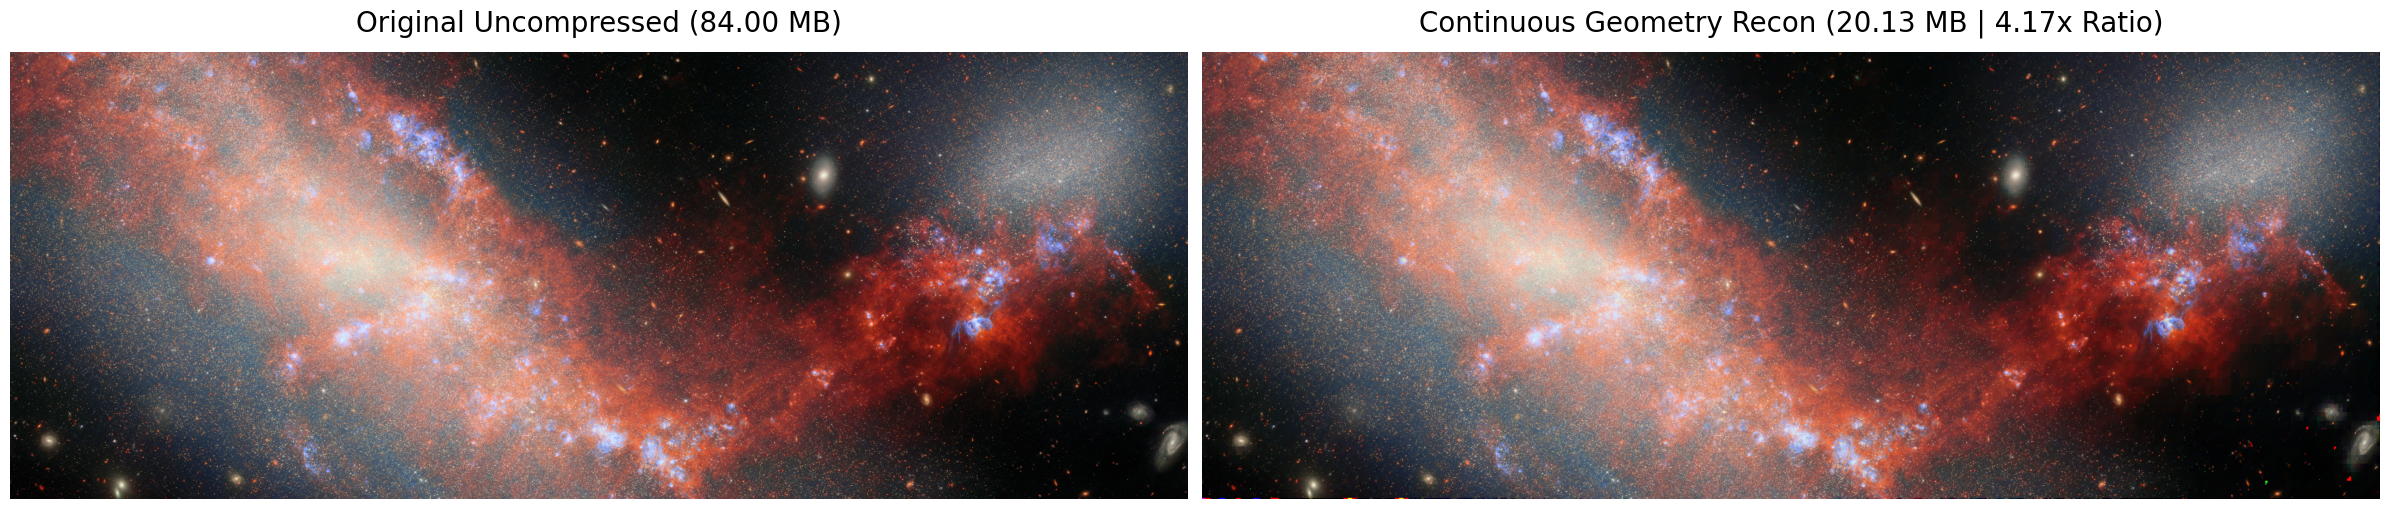

In [16]:
# @title
import matplotlib.pyplot as plt
from PIL import Image

# Load the saved images from the virtual file system
original_img = Image.open("jwst_image.jpg")
reconstructed_img = Image.open("jwst_final_goldilocks.jpg")

# Set up a massive side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# Plot Original
axes[0].imshow(original_img)
axes[0].set_title("Original Uncompressed (84.00 MB)", fontsize=20, pad=15)
axes[0].axis('off')

# Plot Reconstructed
axes[1].imshow(reconstructed_img)
axes[1].set_title("Continuous Geometry Recon (20.13 MB | 4.17x Ratio)", fontsize=20, pad=15)
axes[1].axis('off')

# Render
plt.tight_layout()
plt.show()